# Runs aral sea model using PCR input

In [1]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from pathlib import Path

import pandas as pd
import xarray as xr

import src.aral as aral
from src.constants import STATIONS_PCR
from src.paths import PCR_TEST_ARAL

In [2]:
data = xr.open_dataset(PCR_TEST_ARAL, engine="netcdf4")

In [3]:
# load data
ts_dict = {}
for name, coords in STATIONS_PCR.items():
    ts_dict[name] = data["discharge"].sel(lat=coords["lat"], lon=coords["lon"], method="nearest")

# save as dataframe
df = pd.DataFrame(
    {name: ts.values for name, ts in ts_dict.items()}, index=ts_dict[list(ts_dict.keys())[0]].time
)
df.index.name = "Time"
print(df.tail())

                 Chatly   Kazalinsk       Kerki  Tyumen-Aryk    Karaozek
Time                                                                    
1959-12-27  1183.289551  834.025208  980.529541   707.931091  666.679382
1959-12-28  1324.857422  787.409241  806.217590   748.991638  676.373657
1959-12-29  1372.505859  717.690247  750.146851   790.938721  710.410095
1959-12-30  1338.118774  701.834045  704.558655   770.432983  776.891296
1959-12-31  1564.021118  677.378174  701.110718   883.522949  842.069153


In [4]:
Amu_chatly = aral.River(df, q_col="Chatly", name="Amu Darya - Chatly")
Amu_kerki = aral.River(df, q_col="Kerki", name="Amu Darya - Kerki")
Syr_kaza = aral.River(df, q_col="Kazalinsk", name="Syr Darya - Kazalinsk")
Syr_kara = aral.River(df, q_col="Karaozek", name="Syr Darya - Karaozek")
Syr_tyumen = aral.River(df, q_col="Tyumen-Aryk", name="Syr Darya - Tyumen Aryk")

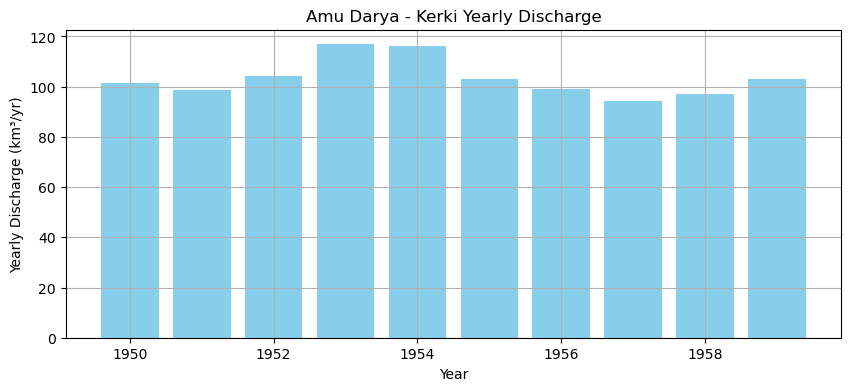

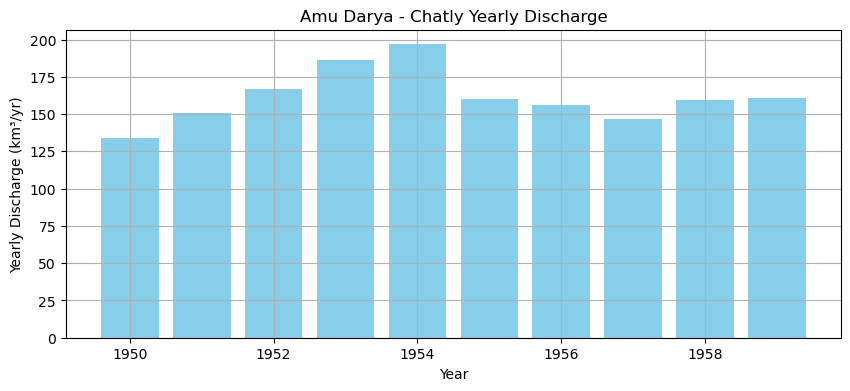

In [5]:
Amu_kerki.plot_yearly()
Amu_chatly.plot_yearly()

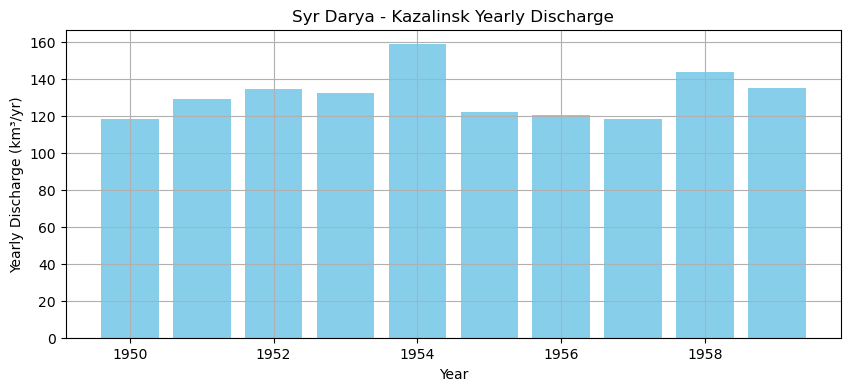

In [6]:
Syr_kaza.plot_yearly()

In [7]:
aral_meteo = xr.open_dataset(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/Derived_Makkink_evspsblpot.nc"
)

# Initial settings
initial_volume = 1100
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"

# Run the model
df_aral = aral.run_connected_aral_model(
    aral_meteo,
    rivers=[Amu_chatly, Syr_kaza],
    ahv_csv=ahv_file,
    V0_km3=initial_volume,
    start_time="1950-01-01",
    end_time="1959-12-31",
    tqdm_position=1,
)

Simulating Aral Sea volume balance:   0%|          | 0/3651 [00:00<?, ?it/s]

In [8]:
observation = aral.make_obs()

Found 4 NetCDF files in /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti


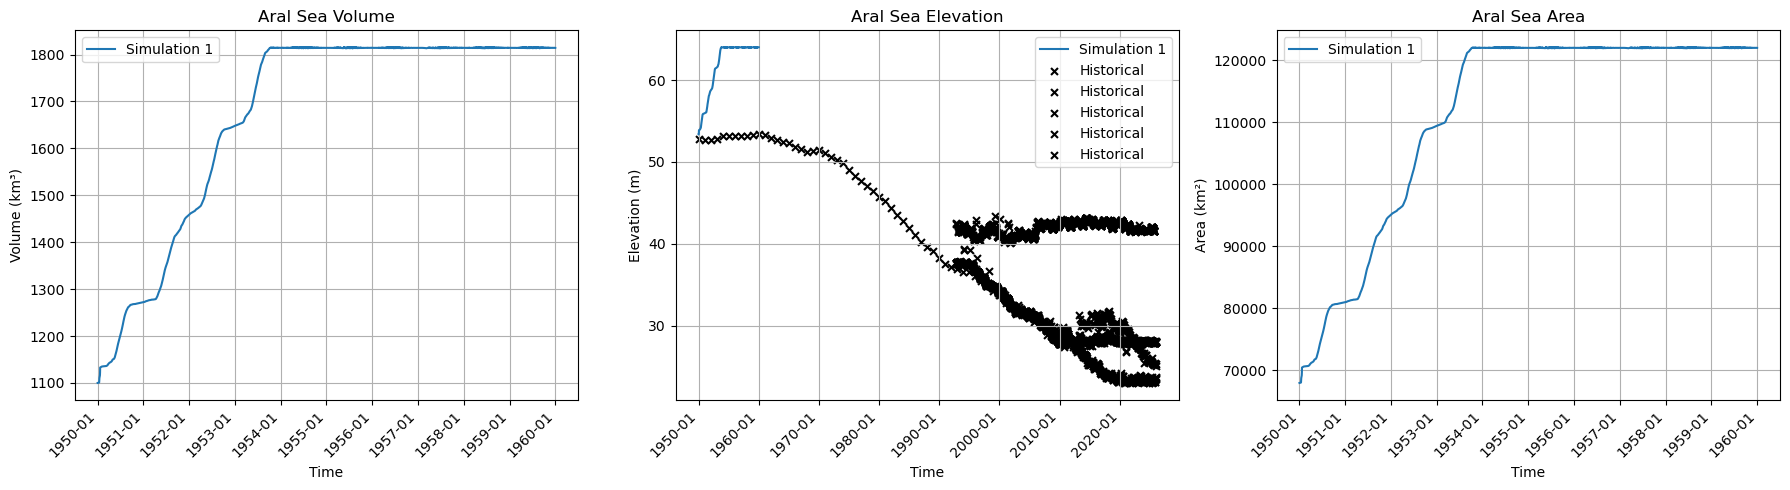

In [9]:
aral.plot_aral_results(df_aral, observations=observation)